# Weather and daily sales

This notebook investigates whether daily weather is associated with the amount sold. It reports the association at **two aggregation levels**, because the level determines the answer:

1. **Sourcing group** (FCM 900, FCM 890, Pseudo 890, Pseudo 900) — one temperature slope per group, pooled over all articles in it. In plot labels, merchandise group 890 is called **Fleisch** and merchandise group 900 **Wurst**.
2. **Article** — one temperature slope per article, which is the level at which the response actually varies.

The group-level result is close to zero for most groups. That is an **aggregation artefact**: articles within a group respond to temperature in opposite directions (grilling cuts up, roasts and stews down), and a common slope averages them out. The article-level section quantifies this directly and tests, with Cochran's *Q* and *I²*, whether the spread of article responses exceeds sampling noise. Both levels are reported so the contrast is visible rather than hidden.

Store coordinates from `data/raw/maerkte/maerkte.csv` are mapped to the nearest 0.25° ERA5 grid cell. Daily temperature, precipitation, and sunshine are assigned from the corresponding cell to every store. Descriptive group-day values use active-series exposure weights; the group-level regression retains the individual product-store series-days, while the article-level regressions pool stores per article-day, because the network's within-day spatial temperature variation is negligible (median SD 0.53 °C).

The main comparison uses the complete available transaction span from 22 July 2023 to 21 July 2026. Each sourcing group contributes every date on which it is observed, so groups with a later introduction have fewer days. Sundays are excluded because stores are generally closed.

The results describe **associations**, not a causal weather effect: regional proxy error, holidays, promotions, and other omitted daily factors may still influence sales.

In [1]:
import os
import re
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/ba-matplotlib")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyfixest as pf
import requests
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT_CANDIDATES = [Path("../.."), Path(".")]
PROJECT_ROOT = next((p.resolve() for p in PROJECT_ROOT_CANDIDATES if (p / "data").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project data directory not found.")

DATA_DIR = PROJECT_ROOT / "data/processed/transactions"
DATA_GLOB = str(DATA_DIR / "*.parquet")
if not any(DATA_DIR.glob("*.parquet")):
    raise FileNotFoundError(f"Processed transaction files not found in {DATA_DIR}")

GROUP_ORDER = ["Gesamt", "FCM Wurst", "FCM Fleisch", "Pseudo Fleisch", "Pseudo Wurst"]
REPORT_GROUP_ORDER = ["Pseudo Fleisch", "Pseudo Wurst", "FCM Wurst", "FCM Fleisch"]
GROUP_COLORS = {
    "Gesamt": "#264653", "FCM Wurst": "#D1495B",
    "FCM Fleisch": "#E76F51", "Pseudo Fleisch": "#2A9D8F",
    "Pseudo Wurst": "#457B9D",
}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})
pd.set_option("display.max_columns", 30)
con = duckdb.connect()
con.execute("PRAGMA threads=4")

Matplotlib is building the font cache; this may take a moment.


## Spatial temperature variability across stores

Each analysed store is assigned to the nearest point of the regular 0.25° ERA5 atmospheric grid. Daily mean 2 m temperature is downloaded once per occupied grid cell with statistical elevation downscaling disabled, then joined back to the stores assigned to that cell. For each date, the population standard deviation (`ddof=0`) is calculated across stores. The median of these daily standard deviations summarizes the typical spatial temperature variation within the store network. The map places the occupied ERA5 cells and store locations over an OpenStreetMap basemap; the histogram shows the distribution over dates.

,analysed stores,occupied ERA5 cells,first date,last date,median daily temperature SD (C)
0,192,73,2023-07-22,2026-07-21,0.527


,count,mean,std,min,10%,25%,50%,75%,90%,max
temperature_std_c,1096.000,0.622,0.307,0.176,0.351,0.412,0.527,0.743,0.996,2.385


Across the 192 analysed stores, the median daily spatial temperature standard deviation is **0.53 °C**. On 90% of dates it does not exceed **1.00 °C**; the remaining right tail represents occasional days with stronger spatial temperature differences across the store network.

,rank,MARKT_ID,ORT,PLZ,mean_absolute_deviation_c,mean_signed_deviation_c,mean_direction,top_deviation_decile_share,variance_contribution_share
0,1,1100012,ESENS,26427,2.60,-0.99,colder than network mean,65.5%,2.7%
1,2,1350052,Dülmen,48249,1.96,+1.53,warmer than network mean,38.2%,1.5%
2,3,1100007,KRUMMHÖRN-PEWSUM,26736,2.00,-0.88,colder than network mean,55.5%,1.5%
3,4,1100084,CUXHAVEN,27472,1.90,-1.00,colder than network mean,38.2%,1.3%
4,5,1250074,Ahlen (Westf.),59229,1.92,+1.39,warmer than network mean,40.0%,1.3%
5,6,1100063,HAGE,26524,1.96,-0.99,colder than network mean,50.9%,1.3%
6,7,1100046,UPGANT-SCHOTT,26529,1.96,-0.99,colder than network mean,50.9%,1.3%
7,8,1100015,SÜDBROOKMERLAND-VICTORBUR,26624,1.96,-0.99,colder than network mean,50.9%,1.3%
8,9,1100016,NORDEN,26506,1.96,-0.99,colder than network mean,50.9%,1.3%
9,10,1100025,HINTE,26759,1.96,-0.99,colder than network mean,50.9%,1.3%


**Which stores drive the right tail?** The right tail contains 110 dates with a daily temperature standard deviation above 1.00 °C. Stores are ranked by their mean squared deviation from the store-network daily mean on those dates, which is their direct contribution to the variance. The result does **not** point primarily to Nordrhein-Westfalen: eight of the ten leading stores are in the northern coastal area (Esens, Krummhörn-Pewsum, Cuxhaven, Hage, Upgant-Schott, Südbrookmerland-Victorbur, Norden, and Hinte) and are on average colder than the network mean. Dülmen and Ahlen are the two Nordrhein-Westfalen stores in the top ten and are on average warmer. The top ten jointly account for 14.7% of squared deviations, so the right tail reflects a distributed north–south temperature contrast rather than a small group of Nordrhein-Westfalen stores. Stores in the same ERA5 cell necessarily receive identical temperature values.

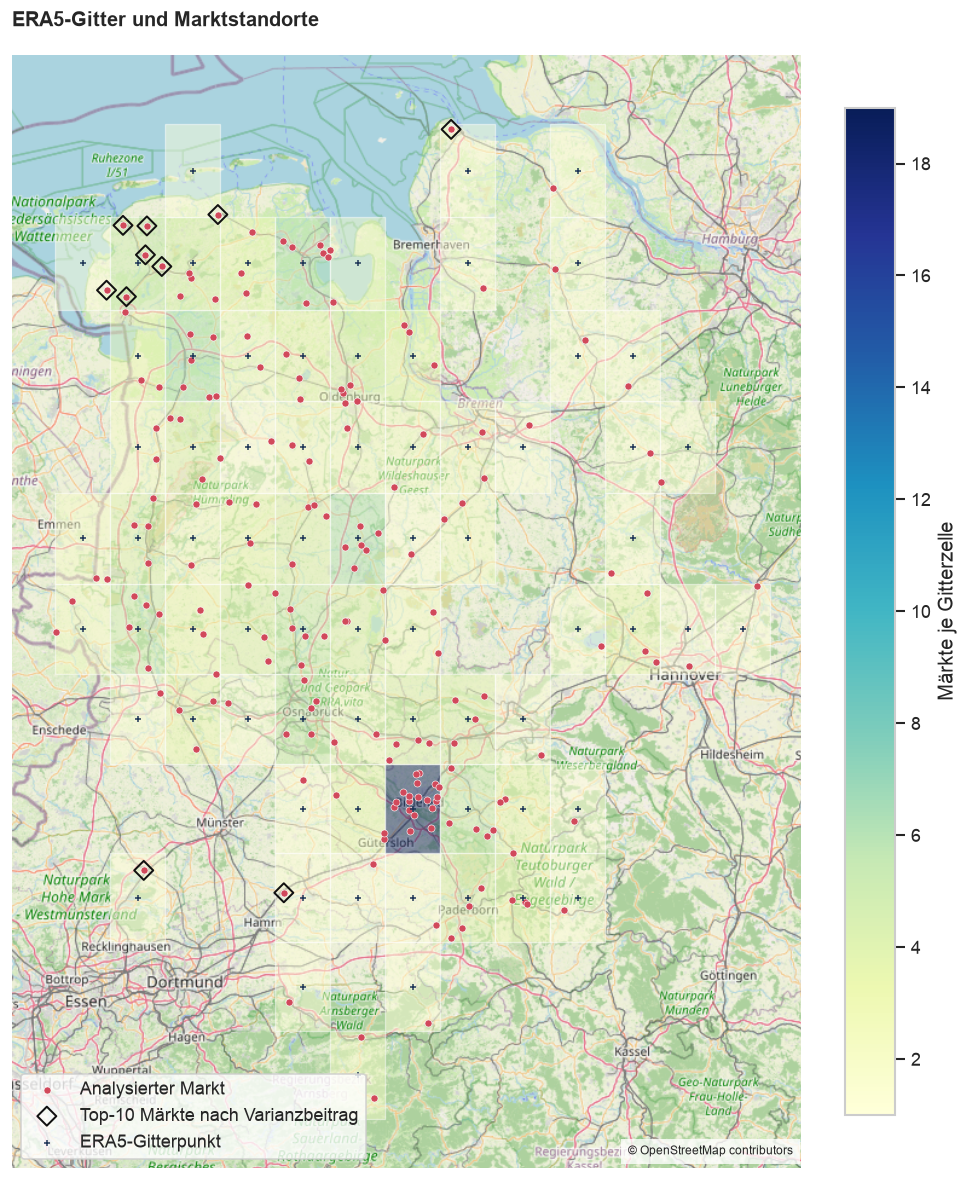

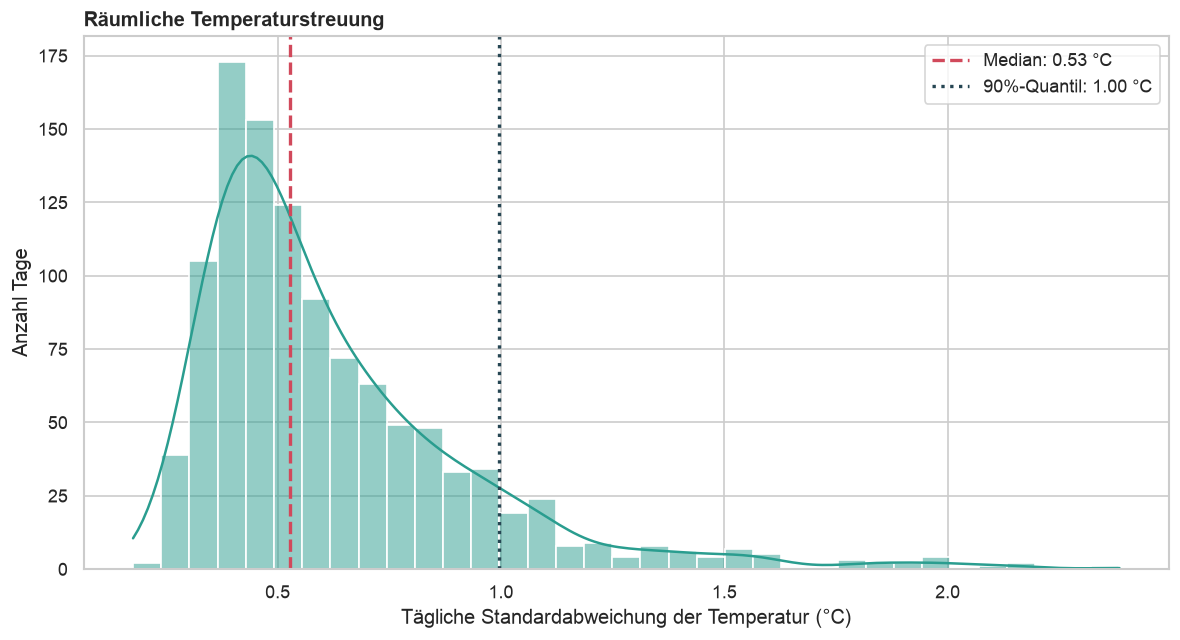

In [2]:
from io import BytesIO
from matplotlib.patches import Rectangle
from PIL import Image
from time import sleep

MARKET_PATH = PROJECT_ROOT / "data/raw/maerkte/maerkte.csv"
ERA5_GRID_DEGREES = 0.25
ERA5_CACHE = PROJECT_ROOT / "data/interim/weather/era5_grid_daily_weather.csv"
ERA5_API_URL = "https://archive-api.open-meteo.com/v1/archive"
OSM_TILE_URL = "https://tile.openstreetmap.org/{z}/{x}/{y}.png"
OSM_TILE_CACHE = PROJECT_ROOT / "data/interim/weather/osm_tiles"
OSM_ZOOM = 8

market_coordinates = pd.read_csv(
    MARKET_PATH, usecols=["MARKT_ID", "ORT", "PLZ", "LONGITUDE", "LATITUDE"]
)
if market_coordinates["MARKT_ID"].duplicated().any():
    raise ValueError("Store metadata contain duplicate MARKT_ID values.")

analysis_market_ids = con.execute(
    f"SELECT DISTINCT MARKT_ID FROM read_parquet('{DATA_GLOB}') ORDER BY MARKT_ID"
).fetchdf()
store_grid = analysis_market_ids.merge(
    market_coordinates, on="MARKT_ID", how="left", validate="one_to_one"
)
if store_grid[["LONGITUDE", "LATITUDE"]].isna().any(axis=None):
    missing = store_grid.loc[
        store_grid[["LONGITUDE", "LATITUDE"]].isna().any(axis=1), "MARKT_ID"
    ].tolist()
    raise ValueError(f"Missing coordinates for analysed stores: {missing}")

def nearest_era5_coordinate(values):
    return (
        np.floor(values.astype(float) / ERA5_GRID_DEGREES + 0.5)
        * ERA5_GRID_DEGREES
    ).round(2)

store_grid["era5_latitude"] = nearest_era5_coordinate(store_grid["LATITUDE"])
store_grid["era5_longitude"] = nearest_era5_coordinate(store_grid["LONGITUDE"])
grid_columns = ["era5_latitude", "era5_longitude"]
era5_cells = (
    store_grid.groupby(grid_columns, as_index=False)
    .agg(stores=("MARKT_ID", "nunique"))
    .sort_values(grid_columns)
    .reset_index(drop=True)
)

analysis_start, analysis_end = con.execute(
    f"SELECT MIN(DATE)::DATE, MAX(DATE)::DATE FROM read_parquet('{DATA_GLOB}')"
).fetchone()
analysis_start = pd.Timestamp(analysis_start)
analysis_end = pd.Timestamp(analysis_end)

def download_era5_daily(
    cells, start_date, end_date, existing=None, cache_path=None, chunk_size=4,
):
    downloaded = [] if existing is None or existing.empty else [existing]
    for offset in range(0, len(cells), chunk_size):
        chunk = cells.iloc[offset:offset + chunk_size]
        params = {
            "latitude": ",".join(chunk.era5_latitude.astype(str)),
            "longitude": ",".join(chunk.era5_longitude.astype(str)),
            "start_date": start_date.strftime("%Y-%m-%d"),
            "end_date": end_date.strftime("%Y-%m-%d"),
            "daily": (
                "temperature_2m_mean,temperature_2m_max,"
                "precipitation_sum,sunshine_duration"
            ),
            "models": "era5",
            "cell_selection": "nearest",
            "elevation": ",".join(["nan"] * len(chunk)),
            "timezone": "Europe/Berlin",
        }
        for attempt, pause_seconds in enumerate([0, 15, 30, 45]):
            if pause_seconds:
                sleep(pause_seconds)
            response = requests.get(ERA5_API_URL, params=params, timeout=120)
            if response.status_code != 429 or attempt == 3:
                break
        response.raise_for_status()
        payload = response.json()
        locations = payload if isinstance(payload, list) else [payload]
        if len(locations) != len(chunk):
            raise RuntimeError(
                f"ERA5 response returned {len(locations)} locations for "
                f"{len(chunk)} requested cells."
            )
        chunk_frames = []
        for cell, location in zip(chunk.itertuples(index=False), locations):
            daily = location["daily"]
            chunk_frames.append(pd.DataFrame({
                "date": pd.to_datetime(daily["time"]),
                "era5_latitude": cell.era5_latitude,
                "era5_longitude": cell.era5_longitude,
                "temperature_mean_c": daily["temperature_2m_mean"],
                "temperature_max_c": daily["temperature_2m_max"],
                "precipitation_mm": daily["precipitation_sum"],
                "sunshine_hours": np.asarray(daily["sunshine_duration"]) / 3600,
            }))
        downloaded.extend(chunk_frames)
        if cache_path is not None:
            cache_path.parent.mkdir(parents=True, exist_ok=True)
            pd.concat(downloaded, ignore_index=True).to_csv(cache_path, index=False)
    return pd.concat(downloaded, ignore_index=True)

if ERA5_CACHE.exists():
    era5_grid_weather = pd.read_csv(ERA5_CACHE, parse_dates=["date"])
else:
    era5_grid_weather = pd.DataFrame()

weather_columns = [
    "temperature_mean_c", "temperature_max_c",
    "precipitation_mm", "sunshine_hours",
]
expected_cells = set(map(tuple, era5_cells[grid_columns].to_numpy()))
required_cache_columns = {"date", *grid_columns, *weather_columns}
complete_cached_cells = set()
if required_cache_columns.issubset(era5_grid_weather.columns):
    for coordinates, cell_weather in era5_grid_weather.groupby(grid_columns):
        if (
            cell_weather.date.min() <= analysis_start
            and cell_weather.date.max() >= analysis_end
            and not cell_weather[weather_columns].isna().any().any()
        ):
            complete_cached_cells.add(tuple(coordinates))
else:
    era5_grid_weather = pd.DataFrame(columns=list(required_cache_columns))

if complete_cached_cells:
    cached_row_index = pd.MultiIndex.from_frame(era5_grid_weather[grid_columns])
    era5_grid_weather = era5_grid_weather[
        cached_row_index.isin(pd.MultiIndex.from_tuples(complete_cached_cells))
    ].copy()
else:
    era5_grid_weather = pd.DataFrame(columns=list(required_cache_columns))

if complete_cached_cells:
    missing_cells = era5_cells[
        ~pd.MultiIndex.from_frame(era5_cells[grid_columns]).isin(
            pd.MultiIndex.from_tuples(complete_cached_cells)
        )
    ]
else:
    missing_cells = era5_cells.copy()
if not missing_cells.empty:
    era5_grid_weather = download_era5_daily(
        missing_cells, analysis_start, analysis_end,
        existing=era5_grid_weather, cache_path=ERA5_CACHE,
    )

era5_grid_weather = era5_grid_weather[
    era5_grid_weather.date.between(analysis_start, analysis_end)
].drop_duplicates(["date", *grid_columns]).copy()
cached_cells = set(map(tuple, era5_grid_weather[grid_columns].drop_duplicates().to_numpy()))
if cached_cells != expected_cells:
    raise ValueError("ERA5 cache does not cover every occupied store grid cell.")
if era5_grid_weather[weather_columns].isna().any().any():
    raise ValueError("ERA5 weather data contain missing values.")

store_temperature = store_grid[["MARKT_ID", *grid_columns]].merge(
    era5_grid_weather, on=grid_columns, how="inner"
)
daily_temperature_spread = (
    store_temperature.groupby("date", as_index=False)
    .agg(
        temperature_std_c=("temperature_mean_c", lambda values: values.std(ddof=0)),
        temperature_min_c=("temperature_mean_c", "min"),
        temperature_max_c=("temperature_mean_c", "max"),
        stores=("MARKT_ID", "nunique"),
    )
)
median_daily_temperature_std = daily_temperature_spread.temperature_std_c.median()

display(pd.DataFrame([{
    "analysed stores": store_grid.MARKT_ID.nunique(),
    "occupied ERA5 cells": len(era5_cells),
    "first date": analysis_start.date(),
    "last date": analysis_end.date(),
    "median daily temperature SD (C)": median_daily_temperature_std,
}]).style.format({"median daily temperature SD (C)": "{:.3f}"}))
display(daily_temperature_spread.temperature_std_c.describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
).to_frame("temperature_std_c").T.style.format("{:.3f}"))
display(Markdown(
    f"Across the {store_grid.MARKT_ID.nunique()} analysed stores, the median "
    f"daily spatial temperature standard deviation is "
    f"**{median_daily_temperature_std:.2f} °C**. On 90% of dates it does not "
    f"exceed **{daily_temperature_spread.temperature_std_c.quantile(0.90):.2f} °C**; "
    "the remaining right tail represents occasional days with stronger spatial "
    "temperature differences across the store network."
))

right_tail_threshold_c = daily_temperature_spread.temperature_std_c.quantile(0.90)
right_tail_dates = daily_temperature_spread.loc[
    daily_temperature_spread.temperature_std_c > right_tail_threshold_c, "date"
]
store_tail_diagnostics = store_temperature.merge(
    store_grid[["MARKT_ID", "ORT", "PLZ", "LONGITUDE", "LATITUDE"]],
    on="MARKT_ID", how="left", validate="many_to_one",
)
store_tail_diagnostics["daily_network_mean_c"] = (
    store_tail_diagnostics.groupby("date").temperature_mean_c.transform("mean")
)
store_tail_diagnostics["signed_deviation_c"] = (
    store_tail_diagnostics.temperature_mean_c
    - store_tail_diagnostics.daily_network_mean_c
)
store_tail_diagnostics["absolute_deviation_c"] = (
    store_tail_diagnostics.signed_deviation_c.abs()
)
store_tail_diagnostics["squared_deviation_c2"] = (
    store_tail_diagnostics.signed_deviation_c ** 2
)
right_tail_store_days = store_tail_diagnostics[
    store_tail_diagnostics.date.isin(right_tail_dates)
].copy()
right_tail_store_days["daily_top_deviation_decile"] = (
    right_tail_store_days.groupby("date").absolute_deviation_c
    .rank(method="min", pct=True).ge(0.90)
)
right_tail_store_summary = (
    right_tail_store_days.groupby(
        ["MARKT_ID", "ORT", "PLZ", "LONGITUDE", "LATITUDE"],
        as_index=False,
    )
    .agg(
        mean_squared_deviation_c2=("squared_deviation_c2", "mean"),
        mean_absolute_deviation_c=("absolute_deviation_c", "mean"),
        mean_signed_deviation_c=("signed_deviation_c", "mean"),
        top_deviation_decile_share=("daily_top_deviation_decile", "mean"),
    )
)
right_tail_store_summary["variance_contribution_share"] = (
    right_tail_store_summary.mean_squared_deviation_c2
    / right_tail_store_summary.mean_squared_deviation_c2.sum()
)
right_tail_store_summary["mean_direction"] = np.where(
    right_tail_store_summary.mean_signed_deviation_c >= 0,
    "warmer than network mean", "colder than network mean",
)
right_tail_top_stores = (
    right_tail_store_summary.sort_values(
        "mean_squared_deviation_c2", ascending=False
    ).head(10).reset_index(drop=True)
)
right_tail_top_stores.insert(0, "rank", np.arange(1, 11))
display(right_tail_top_stores[[
    "rank", "MARKT_ID", "ORT", "PLZ",
    "mean_absolute_deviation_c", "mean_signed_deviation_c",
    "mean_direction", "top_deviation_decile_share",
    "variance_contribution_share",
]].style.format({
    "mean_absolute_deviation_c": "{:.2f}",
    "mean_signed_deviation_c": "{:+.2f}",
    "top_deviation_decile_share": "{:.1%}",
    "variance_contribution_share": "{:.1%}",
}))
top_ten_contribution = right_tail_top_stores.variance_contribution_share.sum()
display(Markdown(
    f"**Which stores drive the right tail?** The right tail contains "
    f"{len(right_tail_dates)} dates with a daily temperature standard deviation "
    f"above {right_tail_threshold_c:.2f} °C. Stores are ranked by their mean "
    "squared deviation from the store-network daily mean on those dates, which "
    "is their direct contribution to the variance. The result does **not** point "
    "primarily to Nordrhein-Westfalen: eight of the ten leading stores are in "
    "the northern coastal area (Esens, Krummhörn-Pewsum, Cuxhaven, Hage, "
    "Upgant-Schott, Südbrookmerland-Victorbur, Norden, and Hinte) and are on "
    "average colder than the network mean. Dülmen and Ahlen are the two "
    "Nordrhein-Westfalen stores in the top ten and are on average warmer. The "
    f"top ten jointly account for {top_ten_contribution:.1%} of squared "
    "deviations, so the right tail reflects a distributed north–south temperature "
    "contrast rather than a small group of Nordrhein-Westfalen stores. Stores in "
    "the same ERA5 cell necessarily receive identical temperature values."
))

WEB_MERCATOR_RADIUS = 6_378_137
WEB_MERCATOR_LIMIT = np.pi * WEB_MERCATOR_RADIUS

def longitude_to_web_mercator(longitude):
    return WEB_MERCATOR_RADIUS * np.deg2rad(longitude)

def latitude_to_web_mercator(latitude):
    latitude_radians = np.deg2rad(np.clip(latitude, -85.05112878, 85.05112878))
    return WEB_MERCATOR_RADIUS * np.log(
        np.tan(np.pi / 4 + latitude_radians / 2)
    )

def longitude_to_tile(longitude, zoom):
    return (np.asarray(longitude) + 180) / 360 * (2 ** zoom)

def latitude_to_tile(latitude, zoom):
    latitude_radians = np.deg2rad(np.clip(latitude, -85.05112878, 85.05112878))
    return (
        1 - np.arcsinh(np.tan(latitude_radians)) / np.pi
    ) / 2 * (2 ** zoom)

def tile_boundary_x(tile_x, zoom):
    return tile_x / (2 ** zoom) * 2 * WEB_MERCATOR_LIMIT - WEB_MERCATOR_LIMIT

def tile_boundary_y(tile_y, zoom):
    return WEB_MERCATOR_LIMIT - tile_y / (2 ** zoom) * 2 * WEB_MERCATOR_LIMIT

def openstreetmap_mosaic(west, south, east, north, zoom=OSM_ZOOM):
    x_min = int(np.floor(longitude_to_tile(west, zoom)))
    x_max = int(np.floor(longitude_to_tile(east, zoom)))
    y_min = int(np.floor(latitude_to_tile(north, zoom)))
    y_max = int(np.floor(latitude_to_tile(south, zoom)))
    tile_size = 256
    mosaic = Image.new(
        "RGB",
        ((x_max - x_min + 1) * tile_size, (y_max - y_min + 1) * tile_size),
    )
    OSM_TILE_CACHE.mkdir(parents=True, exist_ok=True)
    headers = {
        "User-Agent": "BAWeatherAnalysis/1.0 (academic ERA5 map notebook)"
    }
    for tile_y in range(y_min, y_max + 1):
        for tile_x in range(x_min, x_max + 1):
            tile_path = OSM_TILE_CACHE / f"{zoom}_{tile_x}_{tile_y}.png"
            if tile_path.exists():
                tile = Image.open(tile_path).convert("RGB")
            else:
                response = requests.get(
                    OSM_TILE_URL.format(z=zoom, x=tile_x, y=tile_y),
                    headers=headers, timeout=30,
                )
                response.raise_for_status()
                tile = Image.open(BytesIO(response.content)).convert("RGB")
                tile.save(tile_path)
            mosaic.paste(
                tile, ((tile_x - x_min) * tile_size, (tile_y - y_min) * tile_size)
            )
    extent = [
        tile_boundary_x(x_min, zoom), tile_boundary_x(x_max + 1, zoom),
        tile_boundary_y(y_max + 1, zoom), tile_boundary_y(y_min, zoom),
    ]
    return np.asarray(mosaic), extent

map_padding_degrees = 0.20
map_west = store_grid.LONGITUDE.min() - map_padding_degrees
map_east = store_grid.LONGITUDE.max() + map_padding_degrees
map_south = store_grid.LATITUDE.min() - map_padding_degrees
map_north = store_grid.LATITUDE.max() + map_padding_degrees
osm_image, osm_extent = openstreetmap_mosaic(
    map_west, map_south, map_east, map_north
)

map_fig, map_ax = plt.subplots(figsize=(10, 10))
map_ax.imshow(osm_image, extent=osm_extent, interpolation="bilinear", zorder=0)
cell_norm = plt.Normalize(era5_cells.stores.min(), era5_cells.stores.max())
cell_cmap = plt.cm.YlGnBu
for cell in era5_cells.itertuples(index=False):
    cell_left = longitude_to_web_mercator(
        cell.era5_longitude - ERA5_GRID_DEGREES / 2
    )
    cell_right = longitude_to_web_mercator(
        cell.era5_longitude + ERA5_GRID_DEGREES / 2
    )
    cell_bottom = latitude_to_web_mercator(
        cell.era5_latitude - ERA5_GRID_DEGREES / 2
    )
    cell_top = latitude_to_web_mercator(
        cell.era5_latitude + ERA5_GRID_DEGREES / 2
    )
    map_ax.add_patch(Rectangle(
        (cell_left, cell_bottom),
        cell_right - cell_left, cell_top - cell_bottom,
        facecolor=cell_cmap(cell_norm(cell.stores)),
        edgecolor="white", linewidth=0.8, alpha=0.48, zorder=2,
    ))
map_ax.scatter(
    longitude_to_web_mercator(store_grid.LONGITUDE),
    latitude_to_web_mercator(store_grid.LATITUDE),
    s=18, color="#D1495B", edgecolor="white", linewidth=0.35,
    label="Analysierter Markt", zorder=3,
)
map_ax.scatter(
    longitude_to_web_mercator(right_tail_top_stores.LONGITUDE),
    latitude_to_web_mercator(right_tail_top_stores.LATITUDE),
    s=65, marker="D", facecolor="none", edgecolor="#111111",
    linewidth=1.2, label="Top-10 Märkte nach Varianzbeitrag", zorder=4,
)
map_ax.scatter(
    longitude_to_web_mercator(era5_cells.era5_longitude),
    latitude_to_web_mercator(era5_cells.era5_latitude),
    s=12, marker="+", color="#1D3557", linewidth=0.9,
    label="ERA5-Gitterpunkt", zorder=4,
)
map_ax.set_xlim(
    longitude_to_web_mercator(map_west), longitude_to_web_mercator(map_east)
)
map_ax.set_ylim(
    latitude_to_web_mercator(map_south), latitude_to_web_mercator(map_north)
)
map_ax.set_aspect("equal")
map_ax.set_axis_off()
map_ax.set_title("ERA5-Gitter und Marktstandorte", loc="left", weight="bold")
map_ax.legend(loc="lower left", frameon=True)
map_ax.text(
    0.99, 0.01, "© OpenStreetMap contributors",
    transform=map_ax.transAxes, ha="right", va="bottom", fontsize=7,
    bbox={"facecolor": "white", "alpha": 0.78, "edgecolor": "none"},
    zorder=5,
)
colorbar = map_fig.colorbar(
    plt.cm.ScalarMappable(norm=cell_norm, cmap=cell_cmap),
    ax=map_ax, fraction=0.046, pad=0.04,
)
colorbar.set_label("Märkte je Gitterzelle")
map_fig.tight_layout()
plt.show()

distribution_fig, distribution_ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(
    data=daily_temperature_spread, x="temperature_std_c",
    bins=35, kde=True, color="#2A9D8F", ax=distribution_ax,
)
distribution_ax.axvline(
    median_daily_temperature_std, color="#D1495B", linestyle="--",
    linewidth=2, label=f"Median: {median_daily_temperature_std:.2f} °C",
)
distribution_ax.axvline(
    right_tail_threshold_c, color="#264653", linestyle=":",
    linewidth=2, label=f"90%-Quantil: {right_tail_threshold_c:.2f} °C",
)
distribution_ax.set_xlabel("Tägliche Standardabweichung der Temperatur (°C)")
distribution_ax.set_ylabel("Anzahl Tage")
distribution_ax.set_title(
    "Räumliche Temperaturstreuung", loc="left", weight="bold"
)
distribution_ax.legend()
distribution_fig.tight_layout()
plt.show()

## Sales population and available periods

The coverage table reports the available period of each mutually exclusive sourcing group. Descriptive daily values are aggregated within a group, while the fixed-effects model below retains the product-store series-days. Groups are not truncated to a common starting date.

In [3]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE group_store_daily AS
SELECT
    DATE::DATE AS date,
    MARKT_ID,
    CASE
        WHEN is_fcm AND WGR_ID = 900 THEN 'FCM Wurst'
        WHEN is_fcm AND WGR_ID = 890 THEN 'FCM Fleisch'
        WHEN is_pseudo AND WGR_ID = 890 THEN 'Pseudo Fleisch'
        WHEN is_pseudo AND WGR_ID = 900 THEN 'Pseudo Wurst'
    END AS source_group,
    SUM(ABVERKAUFTE_MENGE_KG) AS total_sales_kg,
    COUNT(*) AS active_series
FROM read_parquet('{DATA_GLOB}')
WHERE is_active
  AND WGR_ID IN (890, 900)
  AND ((is_fcm AND NOT is_pseudo) OR (is_pseudo AND NOT is_fcm))
  AND isodow(DATE::DATE) BETWEEN 1 AND 6
GROUP BY DATE::DATE, MARKT_ID, source_group
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE group_daily AS
SELECT
    DATE::DATE AS date,
    CASE
        WHEN is_fcm AND WGR_ID = 900 THEN 'FCM Wurst'
        WHEN is_fcm AND WGR_ID = 890 THEN 'FCM Fleisch'
        WHEN is_pseudo AND WGR_ID = 890 THEN 'Pseudo Fleisch'
        WHEN is_pseudo AND WGR_ID = 900 THEN 'Pseudo Wurst'
    END AS source_group,
    SUM(ABVERKAUFTE_MENGE_KG) AS total_sales_kg,
    COUNT(*) AS active_series,
    COUNT(DISTINCT ARTIKEL_ID) AS products,
    COUNT(DISTINCT MARKT_ID) AS stores
FROM read_parquet('{DATA_GLOB}')
WHERE is_active
  AND WGR_ID IN (890, 900)
  AND ((is_fcm AND NOT is_pseudo) OR (is_pseudo AND NOT is_fcm))
  AND isodow(DATE::DATE) BETWEEN 1 AND 6
GROUP BY DATE::DATE, source_group
""")

group_daily = con.execute("SELECT * FROM group_daily ORDER BY date, source_group").fetchdf()
group_daily["date"] = pd.to_datetime(group_daily["date"])
coverage = (
    group_daily.groupby("source_group", as_index=False)
    .agg(
        first_date=("date", "min"), last_date=("date", "max"),
        observed_days=("date", "nunique"),
        max_products=("products", "max"), max_stores=("stores", "max"),
        total_sales_kg=("total_sales_kg", "sum"),
    )
)
coverage["source_group"] = pd.Categorical(coverage["source_group"], GROUP_ORDER[1:], ordered=True)
coverage = coverage.sort_values("source_group").reset_index(drop=True)
full_start = coverage.first_date.min()
full_end = coverage.last_date.max()
display(coverage)
display(Markdown(
    f"**Full analysis span:** {full_start:%d %B %Y} to {full_end:%d %B %Y}. "
    "Each group contributes its complete available history within this span."
))

,source_group,first_date,last_date,observed_days,max_products,max_stores,total_sales_kg
0,FCM Wurst,2025-04-17,2026-07-21,380,20,190,1.629964e+05
1,FCM Fleisch,2025-09-16,2026-07-21,255,9,149,1.705111e+04
2,Pseudo Fleisch,2023-07-22,2026-07-21,909,279,192,2.199258e+07
3,Pseudo Wurst,2023-07-22,2026-07-21,909,18,155,9.668672e+03


**Full analysis span:** 22 July 2023 to 21 July 2026. Each group contributes its complete available history within this span.

## Weather data

The downstream analysis reuses the ERA5 cell-level weather downloaded above: daily mean and maximum temperature, precipitation, and sunshine duration. Each store therefore receives the weather of its assigned 0.25° grid cell rather than a single proxy location. The cell-level cache under `data/interim/weather/` makes subsequent executions reproducible without another download.

In [4]:
weather = (
    era5_grid_weather[["date", *grid_columns, *weather_columns]]
    .sort_values([*grid_columns, "date"])
    .drop_duplicates([*grid_columns, "date"])
    .copy()
)

expected_cells = store_grid[grid_columns].drop_duplicates().shape[0]
if weather[grid_columns].drop_duplicates().shape[0] != expected_cells:
    raise ValueError("ERA5 weather does not cover every occupied store grid cell.")

display(weather[weather_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
temperature_mean_c,80008.0,10.988431,6.558460,-11.5,6.400000,11.000000,16.300000,30.300000
temperature_max_c,80008.0,14.697167,7.776023,-7.6,8.900000,14.900000,20.400000,38.400000
precipitation_mm,80008.0,2.543944,4.087122,0.0,0.000000,0.600000,3.500000,39.600000
sunshine_hours,80008.0,7.810657,4.899908,0.0,3.743947,8.075067,12.033936,16.645933


## Analysis frame

Both analysis frames use the full available transaction span; they do not truncate all groups to the latest group start. The compact group-day frame retains the descriptive correlations. The fixed-effects regressions use the underlying active product-store series-days: each observation is joined to the ERA5 cell of its store, and `series_id` identifies one store-product combination. This preserves the spatial weather variation and allows inference to be clustered at the series level.

In [5]:
group_store_daily = con.execute(
    "SELECT * FROM group_store_daily ORDER BY date, source_group, MARKT_ID"
).fetchdf()
group_store_daily["date"] = pd.to_datetime(group_store_daily["date"])
group_store_daily = (
    group_store_daily
    .merge(store_grid[["MARKT_ID", *grid_columns]], on="MARKT_ID", how="left", validate="many_to_one")
    .merge(weather, on=["date", *grid_columns], how="left", validate="many_to_one")
)

if group_store_daily[grid_columns].isna().any().any():
    missing_stores = group_store_daily.loc[
        group_store_daily[grid_columns].isna().any(axis=1), "MARKT_ID"
    ].unique()
    raise ValueError(f"Store coordinates are missing for MARKT_ID values: {missing_stores[:10]}")
if group_store_daily[weather_columns].isna().any().any():
    missing_rows = group_store_daily.loc[
        group_store_daily[weather_columns].isna().any(axis=1),
        ["date", "MARKT_ID", *grid_columns],
    ].head(10)
    raise ValueError(f"ERA5 weather is missing for store-date rows:\n{missing_rows}")

for column in weather_columns:
    group_store_daily[f"weighted_{column}"] = (
        group_store_daily[column] * group_store_daily.active_series
    )

def aggregate_store_weather(frame, group_columns):
    aggregation = {
        "total_sales_kg": ("total_sales_kg", "sum"),
        "active_series": ("active_series", "sum"),
        "active_stores": ("MARKT_ID", "nunique"),
        **{f"weighted_{column}": (f"weighted_{column}", "sum") for column in weather_columns},
    }
    result = frame.groupby(group_columns, as_index=False).agg(**aggregation)
    for column in weather_columns:
        result[column] = result.pop(f"weighted_{column}") / result.active_series
    return result

full_store_groups = group_store_daily[
    group_store_daily.date.between(full_start, full_end)
].copy()
full_groups = aggregate_store_weather(
    full_store_groups, ["date", "source_group"]
)
population_daily = aggregate_store_weather(full_store_groups, ["date"])
population_daily["source_group"] = "Gesamt"

analysis = pd.concat([population_daily, full_groups], ignore_index=True)

analysis["sales_per_active_series_kg"] = analysis.total_sales_kg / analysis.active_series
analysis["source_group"] = pd.Categorical(analysis.source_group, GROUP_ORDER, ordered=True)
analysis = analysis.sort_values(["source_group", "date"]).reset_index(drop=True)

analysis_coverage = (
    analysis.groupby("source_group", observed=True)
    .agg(
        days=("date", "nunique"),
        mean_daily_sales_kg=("total_sales_kg", "mean"),
        mean_active_series=("active_series", "mean"),
        mean_active_stores=("active_stores", "mean"),
        mean_kg_per_active_series=("sales_per_active_series_kg", "mean"),
    ).reset_index()
)
display(analysis_coverage)

con.register(
    "store_grid_estimation",
    store_grid[["MARKT_ID", *grid_columns]],
)
con.register(
    "era5_weather_estimation",
    weather[["date", *grid_columns, *weather_columns]],
)
estimation_data = con.execute(f"""
WITH series_daily AS (
    SELECT
        DATE::DATE AS date,
        DENSE_RANK() OVER (ORDER BY MARKT_ID, ARTIKEL_ID) AS series_id,
        MARKT_ID,
        CASE
            WHEN is_fcm AND WGR_ID = 900 THEN 'FCM Wurst'
            WHEN is_fcm AND WGR_ID = 890 THEN 'FCM Fleisch'
            WHEN is_pseudo AND WGR_ID = 890 THEN 'Pseudo Fleisch'
            WHEN is_pseudo AND WGR_ID = 900 THEN 'Pseudo Wurst'
        END AS source_group,
        SUM(ABVERKAUFTE_MENGE_KG)::DOUBLE AS kg
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active
      AND WGR_ID IN (890, 900)
      AND ((is_fcm AND NOT is_pseudo) OR (is_pseudo AND NOT is_fcm))
      AND isodow(DATE::DATE) BETWEEN 1 AND 6
      AND DATE::DATE BETWEEN DATE '{full_start:%Y-%m-%d}' AND DATE '{full_end:%Y-%m-%d}'
    GROUP BY DATE::DATE, MARKT_ID, ARTIKEL_ID, source_group
)
SELECT
    sales.date, sales.series_id, sales.source_group, sales.kg,
    weather.temperature_mean_c AS temp_c,
    weather.precipitation_mm AS precip_mm,
    weather.sunshine_hours AS sun_h
FROM series_daily AS sales
LEFT JOIN store_grid_estimation AS stores USING (MARKT_ID)
LEFT JOIN era5_weather_estimation AS weather
  ON sales.date = weather.date
 AND stores.era5_latitude = weather.era5_latitude
 AND stores.era5_longitude = weather.era5_longitude
ORDER BY sales.series_id, sales.date
""").fetchdf()
estimation_data = estimation_data.rename(columns={"source_group": "group"})

if estimation_data[["temp_c", "precip_mm", "sun_h"]].isna().any().any():
    raise ValueError("ERA5 weather is missing for at least one estimation row.")
if estimation_data.duplicated(["series_id", "date"]).any():
    raise ValueError("The estimation frame contains duplicate series-date rows.")

estimation_data["group"] = pd.Categorical(
    estimation_data.group, categories=REPORT_GROUP_ORDER, ordered=True
)
estimation_data["year_month"] = (
    estimation_data.date.dt.year * 100 + estimation_data.date.dt.month
).astype("int16")
estimation_data["weekday"] = estimation_data.date.dt.dayofweek.astype("int8")
estimation_data["series_id"] = estimation_data.series_id.astype("int32")
for column in ["kg", "temp_c", "precip_mm", "sun_h"]:
    estimation_data[column] = estimation_data[column].astype("float32")

display(pd.DataFrame([{
    "series-day observations": len(estimation_data),
    "series": estimation_data.series_id.nunique(),
    "days": estimation_data.date.nunique(),
    "ERA5 cells represented": store_grid[grid_columns].drop_duplicates().shape[0],
}]))

,source_group,days,mean_daily_sales_kg,mean_active_series,mean_active_stores,mean_kg_per_active_series
0,Gesamt,909,24402.963845,18468.817382,184.657866,1.345130
1,FCM Wurst,380,428.937978,1978.360526,183.715789,0.228815
2,FCM Fleisch,255,66.867107,263.588235,133.054902,0.284947
3,Pseudo Fleisch,909,24194.255137,17517.390539,184.657866,1.391409
4,Pseudo Wurst,909,10.636603,50.445545,35.618262,0.242680


,series-day observations,series,days,ERA5 cells represented
0,16788155,21983,909,73


## Descriptive weather correlations

Spearman correlations show whether warmer, wetter, or sunnier days tend to rank together with higher sales per active product-store series. These are deliberately labelled *unadjusted*: temperature and sunshine follow the annual cycle, while sales also have seasonal and weekday patterns. The regression section therefore provides the more informative comparison.

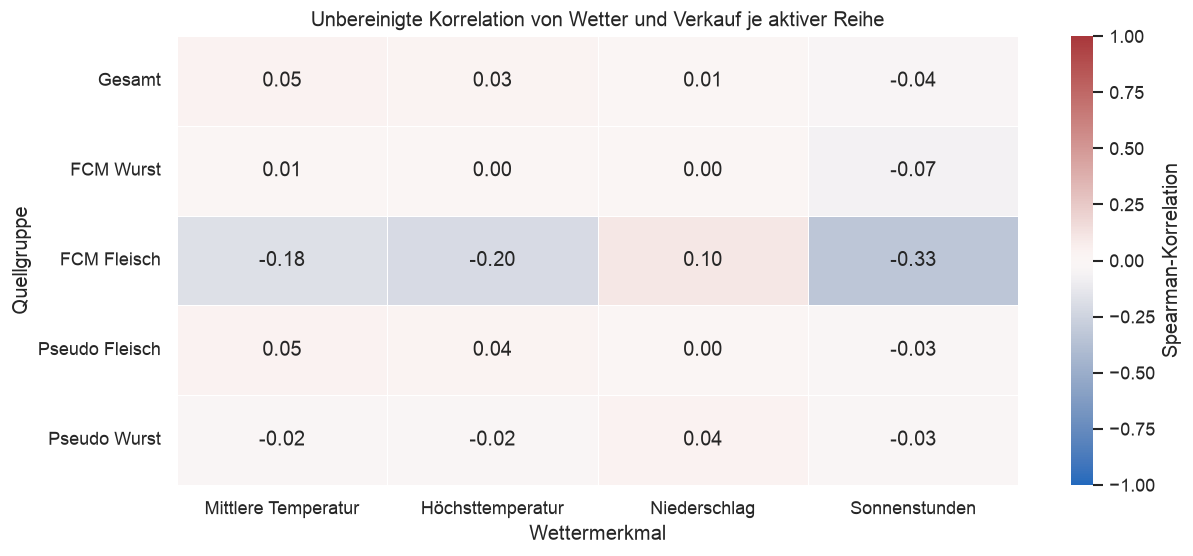

In [6]:
weather_variables = {
    "temperature_mean_c": "Mittlere Temperatur",
    "temperature_max_c": "Höchsttemperatur",
    "precipitation_mm": "Niederschlag",
    "sunshine_hours": "Sonnenstunden",
}
correlation_rows = []
for source_group, part in analysis.groupby("source_group", observed=True):
    for variable, german_label in weather_variables.items():
        correlation_rows.append({
            "source_group": str(source_group),
            "weather_variable": german_label,
            "spearman_correlation": part.sales_per_active_series_kg.corr(part[variable], method="spearman"),
        })
correlations = pd.DataFrame(correlation_rows)
correlation_matrix = correlations.pivot(
    index="source_group", columns="weather_variable", values="spearman_correlation"
).reindex(index=GROUP_ORDER, columns=list(weather_variables.values()))

fig, ax = plt.subplots(figsize=(10.5, 4.8))
sns.heatmap(
    correlation_matrix, annot=True, fmt=".2f", center=0, cmap="vlag",
    vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"label": "Spearman-Korrelation"}, ax=ax,
)
ax.set_xlabel("Wettermerkmal")
ax.set_ylabel("Quellgruppe")
ax.set_title("Unbereinigte Korrelation von Wetter und Verkauf je aktiver Reihe")
plt.tight_layout()
plt.show()

## Adjusted temperature association — sourcing-group level

A single pooled fixed-effects model is estimated on active product-store series-days:

`kg ~ temp_c:C(group) + precip_mm:C(group) + sun_h:C(group) | series_id + group^year_month + group^weekday`.

The interacted slopes report a separate weather association for every sourcing group while using one common estimation. Series fixed effects absorb time-invariant differences between store-product combinations; group-specific year-month and weekday fixed effects absorb calendar patterns. Standard errors are clustered by `series_id`. Effects are absolute kilograms per active series-day and are scaled to a 10 °C change for the table.

**Interpret these coefficients as group averages, not as "the" weather effect.** Each one constrains every article in the group to share a single slope, so a group whose articles respond in opposite directions will show a near-zero coefficient regardless of how strong the individual responses are. Precipitation and sunshine enter as group-specific controls; their coefficients are estimated but not reported here, since the article-level section below shows temperature to be the dominant weather channel. The article-level estimates that follow are the ones to use for modelling decisions.

In [7]:
LINEAR_FML = (
    "kg ~ temp_c:C(group) + precip_mm:C(group) + sun_h:C(group) "
    "| series_id + group^year_month + group^weekday"
)
linear_model = pf.feols(
    LINEAR_FML, data=estimation_data, vcov={"CRV1": "series_id"},
    copy_data=False, store_data=False, lean=True,
)
linear_tidy = linear_model.tidy()

hot_days = (
    estimation_data.loc[estimation_data.temp_c >= 20]
    .groupby("group", observed=True).date.nunique().astype(int)
)
group_volume = estimation_data.groupby("group", observed=True).kg.sum()
volume_share = group_volume / group_volume.sum()

model_rows = []
for source_group in REPORT_GROUP_ORDER:
    term = f"temp_c:C(group)[{source_group}]"
    result = linear_tidy.loc[term]
    model_rows.append({
        "source_group": source_group,
        "effect_per_10c_kg": 10 * result["Estimate"],
        "ci_low_kg": 10 * result["2.5%"],
        "ci_high_kg": 10 * result["97.5%"],
        "p_value": result["Pr(>|t|)"],
        "days_ge_20c": int(hot_days.loc[source_group]),
        "volume_share": volume_share.loc[source_group],
    })
weather_effects = pd.DataFrame(model_rows)

In [8]:
def format_p_value(value):
    return "<0.001" if value < 0.001 else f"{value:.3f}"

results_table = weather_effects.assign(
    **{"95% CI": lambda frame: frame.apply(
        lambda row: f"[{row.ci_low_kg:+.3f}, {row.ci_high_kg:+.3f}] kg", axis=1
    )}
).rename(columns={
    "source_group": "Group",
    "effect_per_10c_kg": "Effect per +10 °C",
    "p_value": "p",
    "days_ge_20c": "Days ≥ 20 °C",
    "volume_share": "Volume share",
})[["Group", "Effect per +10 °C", "95% CI", "p", "Days ≥ 20 °C", "Volume share"]]

display(results_table.style.hide(axis="index").format({
    "Effect per +10 °C": lambda value: f"{value:+.3f} kg",
    "p": format_p_value,
    "Days ≥ 20 °C": "{:d}",
    "Volume share": "{:.1%}",
}))
display(Markdown(
    "*Days ≥ 20 °C counts distinct dates with at least one active series-day "
    "in the group assigned an ERA5 cell temperature of at least 20 °C.*"
))

Group,Effect per +10 °C,95% CI,p,Days ≥ 20 °C,Volume share
Pseudo Fleisch,+0.093 kg,"[+0.079, +0.106] kg",<0.001,125,99.1%
Pseudo Wurst,+0.006 kg,"[-0.007, +0.019] kg",0.392,103,0.0%
FCM Wurst,-0.002 kg,"[-0.007, +0.002] kg",0.331,57,0.7%
FCM Fleisch,-0.041 kg,"[-0.062, -0.020] kg",<0.001,26,0.1%


*Days ≥ 20 °C counts distinct dates with at least one active series-day in the group assigned an ERA5 cell temperature of at least 20 °C.*

## Estimation audit

The following audit confirms that all sourcing-group slopes come from the same estimation and that inference is clustered over the product-store series rather than treating series-days as independent observations.

In [9]:
series_by_group = (
    estimation_data.groupby("group", observed=True)
    .agg(
        observations=("kg", "size"),
        clustered_series=("series_id", "nunique"),
        days=("date", "nunique"),
    )
    .reindex(REPORT_GROUP_ORDER)
)
display(series_by_group)
display(Markdown(
    f"**One pooled fit:** {len(estimation_data):,} series-day observations, "
    f"{estimation_data.series_id.nunique():,} series clusters, and "
    f"{estimation_data.date.nunique()} trading days."
))

,observations,clustered_series,days
group,,,
Pseudo Fleisch,15923308,18628,909
Pseudo Wurst,45855,243,909
FCM Wurst,751777,2791,380
FCM Fleisch,67215,321,255


**One pooled fit:** 16,788,155 series-day observations, 21,983 series clusters, and 909 trading days.

## Article-level temperature response

The pooled model above estimates **one slope per sourcing group**, which is the wrong
aggregation level for this question. A sourcing group contains hundreds of articles whose
demand can respond to temperature in *opposite* directions — grilling cuts rise in warm
weather while roasts, stews, and soup meat fall. A single group slope is a volume-weighted
average over those opposing responses, so it is driven toward zero even when the individual
responses are large. A group-level null is therefore not evidence that temperature is
irrelevant; it is consistent with substantial but mutually cancelling article effects.

This section re-estimates the association at the **article × day** level:

- **Stores are pooled per article and day.** The weather signal has almost no within-day
  spatial variation across this network (median daily spatial temperature SD 0.53 °C, see
  above), so the store dimension multiplies the number of rows without adding identifying
  variation for weather. The article dimension is where the response actually differs.
- **The outcome is demand per active store-day in kilograms**, so a changing number of
  active stores does not drive the estimate.
- **Each article receives its own regression** with its own year-month and weekday fixed
  effects, so no cross-article restriction is imposed on the slope.
- **Standard errors are clustered by ISO week.** Both temperature and demand are strongly
  autocorrelated within a week, and day-level heteroskedasticity-only inference would
  overstate precision substantially.

Whether the spread of the resulting slopes is genuine or merely sampling noise is tested
explicitly below with Cochran's *Q* and *I²*.

In [10]:
MIN_ARTICLE_DAYS = 120
MIN_ARTICLE_WEEKS = 20

product_daily = con.execute(f"""
WITH series_daily AS (
    SELECT
        DATE::DATE AS date,
        ARTIKEL_ID AS product_id,
        MARKT_ID,
        CASE
            WHEN is_fcm AND WGR_ID = 900 THEN 'FCM Wurst'
            WHEN is_fcm AND WGR_ID = 890 THEN 'FCM Fleisch'
            WHEN is_pseudo AND WGR_ID = 890 THEN 'Pseudo Fleisch'
            WHEN is_pseudo AND WGR_ID = 900 THEN 'Pseudo Wurst'
        END AS source_group,
        SUM(ABVERKAUFTE_MENGE_KG)::DOUBLE AS kg
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active
      AND WGR_ID IN (890, 900)
      AND ((is_fcm AND NOT is_pseudo) OR (is_pseudo AND NOT is_fcm))
      AND isodow(DATE::DATE) BETWEEN 1 AND 6
      AND DATE::DATE BETWEEN DATE '{full_start:%Y-%m-%d}' AND DATE '{full_end:%Y-%m-%d}'
    GROUP BY DATE::DATE, ARTIKEL_ID, MARKT_ID, source_group
)
SELECT
    sales.date,
    sales.product_id,
    sales.source_group,
    SUM(sales.kg) AS total_kg,
    COUNT(*) AS active_series,
    SUM(weather.temperature_mean_c) / COUNT(*) AS temp_c,
    SUM(weather.precipitation_mm) / COUNT(*) AS precip_mm,
    SUM(weather.sunshine_hours) / COUNT(*) AS sun_h
FROM series_daily AS sales
LEFT JOIN store_grid_estimation AS stores USING (MARKT_ID)
LEFT JOIN era5_weather_estimation AS weather
  ON sales.date = weather.date
 AND stores.era5_latitude = weather.era5_latitude
 AND stores.era5_longitude = weather.era5_longitude
GROUP BY sales.date, sales.product_id, sales.source_group
ORDER BY sales.product_id, sales.date
""").fetchdf()

product_daily["date"] = pd.to_datetime(product_daily["date"])
if product_daily[["temp_c", "precip_mm", "sun_h"]].isna().any().any():
    raise ValueError("ERA5 weather is missing for at least one article-day row.")
if product_daily.duplicated(["product_id", "date"]).any():
    raise ValueError("The article-day frame contains duplicate product-date rows.")

# Weather per article-day is the active-series-weighted mean over the stores that
# actually sold the article that day, matching the exposure weighting used above.
product_daily["kg"] = product_daily.total_kg / product_daily.active_series
product_daily["year_month"] = (
    product_daily.date.dt.year * 100 + product_daily.date.dt.month
).astype("int32")
product_daily["weekday"] = product_daily.date.dt.dayofweek.astype("int8")
iso_calendar = product_daily.date.dt.isocalendar()
product_daily["iso_week"] = (
    iso_calendar.year * 100 + iso_calendar.week
).astype("int32")

display(pd.DataFrame([{
    "article-day observations": len(product_daily),
    "articles": product_daily.product_id.nunique(),
    "days": product_daily.date.nunique(),
    "ISO weeks": product_daily.iso_week.nunique(),
    "mean kg per active store-day": product_daily.kg.mean(),
}]).style.hide(axis="index").format({"mean kg per active store-day": "{:.3f}"}))

article-day observations,articles,days,ISO weeks,mean kg per active store-day
257163,326,909,158,0.780


In [11]:
ARTICLE_FML = "kg ~ temp_c + precip_mm + sun_h | year_month + weekday"

article_rows = []
skipped_articles = 0
for product_id, product_frame in product_daily.groupby("product_id", sort=True):
    enough_support = (
        product_frame.date.nunique() >= MIN_ARTICLE_DAYS
        and product_frame.iso_week.nunique() >= MIN_ARTICLE_WEEKS
        and product_frame.temp_c.std() > 0
        and product_frame.year_month.nunique() > 1
    )
    if not enough_support:
        skipped_articles += 1
        continue
    try:
        article_model = pf.feols(
            ARTICLE_FML, data=product_frame, vcov={"CRV1": "iso_week"},
            copy_data=True, store_data=False, lean=True,
        )
        estimate = article_model.tidy().loc["temp_c"]
    except Exception:
        skipped_articles += 1
        continue
    article_rows.append({
        "product_id": product_id,
        "source_group": product_frame.source_group.iloc[0],
        "slope_kg_per_c": estimate["Estimate"],
        "std_error": estimate["Std. Error"],
        "ci_low_kg_per_c": estimate["2.5%"],
        "ci_high_kg_per_c": estimate["97.5%"],
        "p_value": estimate["Pr(>|t|)"],
        "mean_kg": product_frame.kg.mean(),
        "volume_kg": product_frame.total_kg.sum(),
        "days": product_frame.date.nunique(),
    })

article_slopes = pd.DataFrame(article_rows)
article_slopes["effect_per_10c_kg"] = 10 * article_slopes.slope_kg_per_c
article_slopes["relative_per_10c"] = (
    article_slopes.effect_per_10c_kg / article_slopes.mean_kg
)
article_slopes["ci_excludes_zero"] = (
    (article_slopes.ci_low_kg_per_c > 0) | (article_slopes.ci_high_kg_per_c < 0)
)
article_slopes["direction"] = np.where(
    article_slopes.slope_kg_per_c >= 0, "positive", "negative"
)

# Cochran's Q and I^2: is the spread of slopes larger than their sampling noise?
inverse_variance = 1 / article_slopes.std_error ** 2
precision_weighted_mean = (
    (inverse_variance * article_slopes.slope_kg_per_c).sum() / inverse_variance.sum()
)
cochran_q = (
    inverse_variance * (article_slopes.slope_kg_per_c - precision_weighted_mean) ** 2
).sum()
degrees_of_freedom = len(article_slopes) - 1
i_squared = max(0.0, (cochran_q - degrees_of_freedom) / cochran_q)
tau_squared = max(0.0, (cochran_q - degrees_of_freedom) / (
    inverse_variance.sum() - (inverse_variance ** 2).sum() / inverse_variance.sum()
))
between_article_sd = np.sqrt(tau_squared)
median_standard_error = article_slopes.std_error.median()

volume_weighted_effect = np.average(
    article_slopes.effect_per_10c_kg, weights=article_slopes.volume_kg
)
volume_weighted_relative = np.average(
    article_slopes.relative_per_10c, weights=article_slopes.volume_kg
)
significant_slopes = article_slopes[article_slopes.ci_excludes_zero]

article_summary = pd.DataFrame([
    {"Statistic": "Articles estimated", "Value": f"{len(article_slopes):d}"},
    {"Statistic": "Articles skipped (insufficient support)", "Value": f"{skipped_articles:d}"},
    {"Statistic": "95% CI excludes zero", "Value": (
        f"{len(significant_slopes):d} "
        f"({len(significant_slopes) / len(article_slopes):.1%})"
    )},
    {"Statistic": "…of which positive / negative", "Value": (
        f"{(significant_slopes.direction == 'positive').sum():d} / "
        f"{(significant_slopes.direction == 'negative').sum():d}"
    )},
    {"Statistic": "Volume-weighted mean effect per +10 °C", "Value": (
        f"{volume_weighted_effect:+.4f} kg ({volume_weighted_relative:+.2%} of mean)"
    )},
    {"Statistic": "Relative effect p10 / median / p90", "Value": (
        f"{article_slopes.relative_per_10c.quantile(0.10):+.1%} / "
        f"{article_slopes.relative_per_10c.median():+.1%} / "
        f"{article_slopes.relative_per_10c.quantile(0.90):+.1%}"
    )},
    {"Statistic": "Cochran Q (df)", "Value": (
        f"{cochran_q:,.0f} ({degrees_of_freedom:d})"
    )},
    {"Statistic": "I² (share of dispersion beyond sampling noise)", "Value": f"{i_squared:.1%}"},
    {"Statistic": "Between-article SD τ vs median SE", "Value": (
        f"{between_article_sd:.4f} vs {median_standard_error:.4f} kg/°C"
    )},
])
display(article_summary.style.hide(axis="index"))

top_volume_articles = article_slopes.nlargest(12, "volume_kg").assign(
    **{"95% CI": lambda frame: frame.apply(
        lambda row: f"[{10 * row.ci_low_kg_per_c:+.3f}, {10 * row.ci_high_kg_per_c:+.3f}]",
        axis=1,
    )}
).rename(columns={
    "product_id": "Article",
    "source_group": "Group",
    "effect_per_10c_kg": "Effect per +10 °C",
    "relative_per_10c": "Relative",
    "p_value": "p",
    "mean_kg": "Mean kg/store-day",
})[[
    "Article", "Group", "Effect per +10 °C", "Relative", "95% CI", "p",
    "Mean kg/store-day",
]]
display(top_volume_articles.style.hide(axis="index").format({
    "Effect per +10 °C": "{:+.3f} kg",
    "Relative": "{:+.1%}",
    "p": format_p_value,
    "Mean kg/store-day": "{:.2f}",
}))
display(Markdown(
    "*The twelve highest-volume articles. `Relative` expresses the same effect as a "
    "share of that article's mean demand per active store-day.*"
))

/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


/Users/vlada/UNI/SoSe2026/ba/ba_code/.venv/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


Statistic,Value
Articles estimated,316
Articles skipped (insufficient support),10
95% CI excludes zero,126 (39.9%)
…of which positive / negative,86 / 40
Volume-weighted mean effect per +10 °C,+0.0281 kg (+7.09% of mean)
Relative effect p10 / median / p90,-36.9% / +3.7% / +83.1%
Cochran Q (df),"2,181 (315)"
I² (share of dispersion beyond sampling noise),85.6%
Between-article SD τ vs median SE,0.0052 vs 0.0048 kg/°C


Article,Group,Effect per +10 °C,Relative,95% CI,p,Mean kg/store-day
316623,Pseudo Fleisch,-1.568 kg,-9.2%,"[-6.168, +3.033]",0.502,17.03
317045,Pseudo Fleisch,-1.293 kg,-18.9%,"[-3.545, +0.959]",0.259,6.82
317123,Pseudo Fleisch,+5.023 kg,+76.1%,"[+3.471, +6.575]",<0.001,6.60
316627,Pseudo Fleisch,-0.289 kg,-4.5%,"[-1.185, +0.608]",0.526,6.35
316629,Pseudo Fleisch,-0.268 kg,-5.5%,"[-1.385, +0.848]",0.636,4.84
316638,Pseudo Fleisch,-0.450 kg,-12.6%,"[-1.508, +0.608]",0.402,3.58
316783,Pseudo Fleisch,-0.312 kg,-9.3%,"[-1.336, +0.712]",0.548,3.37
316810,Pseudo Fleisch,-1.157 kg,-35.0%,"[-3.080, +0.765]",0.236,3.30
316646,Pseudo Fleisch,+0.157 kg,+4.9%,"[-0.644, +0.959]",0.699,3.22
316835,Pseudo Fleisch,-0.666 kg,-22.2%,"[-1.887, +0.555]",0.283,3.00


*The twelve highest-volume articles. `Relative` expresses the same effect as a share of that article's mean demand per active store-day.*

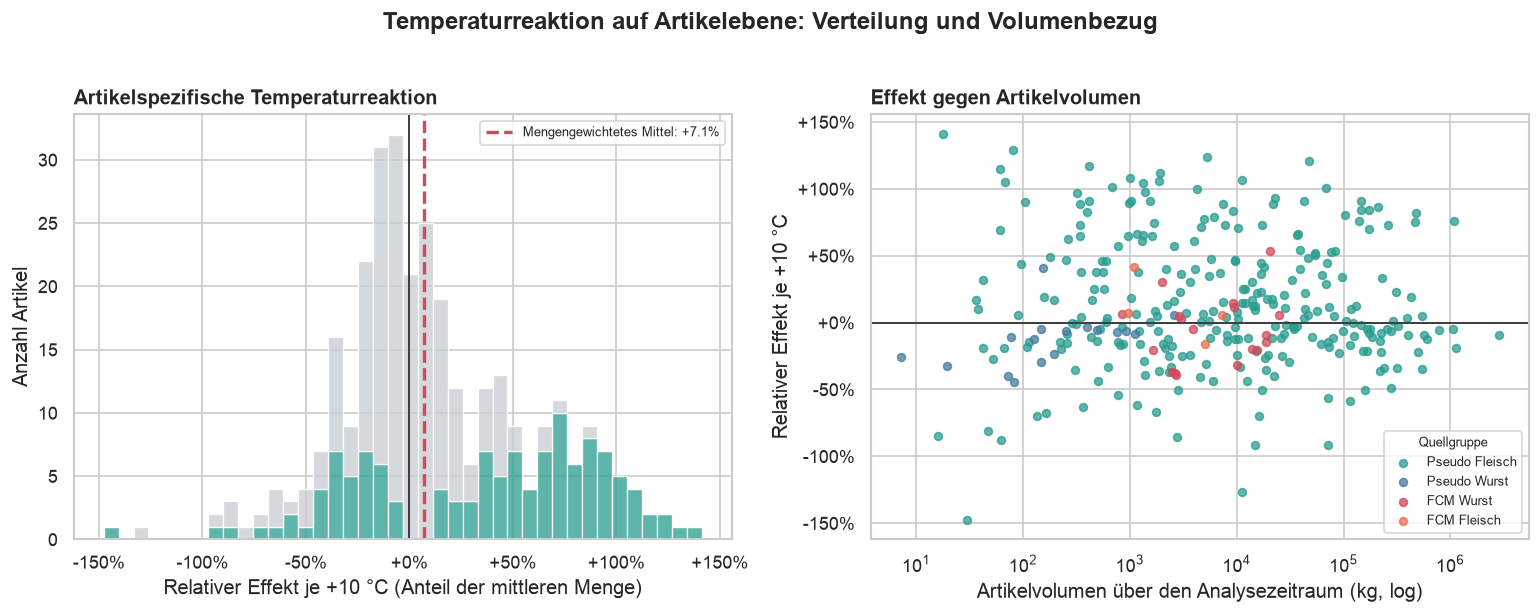

In [12]:
article_figure, article_axes = plt.subplots(1, 2, figsize=(13, 5))

distribution_axis = article_axes[0]
sns.histplot(
    data=article_slopes, x="relative_per_10c", bins=40,
    hue="ci_excludes_zero", multiple="stack",
    palette={True: "#2A9D8F", False: "#C7CCD1"},
    ax=distribution_axis,
)
distribution_axis.axvline(0, color="0.25", linewidth=1.2)
distribution_axis.axvline(
    volume_weighted_relative, color="#D1495B", linestyle="--", linewidth=2,
    label=f"Mengengewichtetes Mittel: {volume_weighted_relative:+.1%}",
)
distribution_axis.set_xlabel("Relativer Effekt je +10 °C (Anteil der mittleren Menge)")
distribution_axis.set_ylabel("Anzahl Artikel")
distribution_axis.set_title(
    "Artikelspezifische Temperaturreaktion", loc="left", weight="bold",
)
distribution_axis.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:+.0%}")
)
handles, labels = distribution_axis.get_legend_handles_labels()
if distribution_axis.get_legend() is not None:
    distribution_axis.get_legend().remove()
distribution_axis.legend(handles, labels, loc="upper right", fontsize=8)

volume_axis = article_axes[1]
for source_group in REPORT_GROUP_ORDER:
    panel = article_slopes[article_slopes.source_group == source_group]
    if panel.empty:
        continue
    volume_axis.scatter(
        panel.volume_kg, panel.relative_per_10c,
        s=22, alpha=0.75, color=GROUP_COLORS[source_group], label=source_group,
    )
volume_axis.axhline(0, color="0.25", linewidth=1.2)
volume_axis.set_xscale("log")
volume_axis.set_xlabel("Artikelvolumen über den Analysezeitraum (kg, log)")
volume_axis.set_ylabel("Relativer Effekt je +10 °C")
volume_axis.set_title(
    "Effekt gegen Artikelvolumen", loc="left", weight="bold",
)
volume_axis.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:+.0%}")
)
volume_axis.legend(fontsize=8, title="Quellgruppe", title_fontsize=8)

article_figure.suptitle(
    "Temperaturreaktion auf Artikelebene: Verteilung und Volumenbezug",
    y=1.02, weight="bold",
)
article_figure.tight_layout()
plt.show()

In [13]:
pooled_pseudo_fleisch = weather_effects.loc[
    weather_effects.source_group == "Pseudo Fleisch"
].iloc[0]
positive_significant = int((significant_slopes.direction == "positive").sum())
negative_significant = int((significant_slopes.direction == "negative").sum())
null_significance_rate = 0.05

display(Markdown(
    "**Reading the article-level estimates.**\n\n"
    f"- **The pooled group slope is reproduced as an average.** Volume-weighting the "
    f"{len(article_slopes)} article slopes gives {volume_weighted_effect:+.4f} kg per "
    f"+10 °C, or {volume_weighted_relative:+.2%} of mean demand — the same order as the "
    f"pooled Pseudo-Fleisch estimate of {pooled_pseudo_fleisch.effect_per_10c_kg:+.3f} kg. "
    "The group-level model is therefore not wrong; it answers a different, less useful "
    "question.\n"
    f"- **But it hides opposing responses.** {len(significant_slopes)} of "
    f"{len(article_slopes)} articles "
    f"({len(significant_slopes) / len(article_slopes):.1%}) have a week-clustered 95% "
    f"confidence interval excluding zero — {positive_significant} positive and "
    f"{negative_significant} negative. Under a true null of no effect anywhere, roughly "
    f"{null_significance_rate:.0%} would be expected.\n"
    f"- **The spread is economically large.** The relative effect per +10 °C runs from "
    f"{article_slopes.relative_per_10c.quantile(0.10):+.1%} at the 10th percentile to "
    f"{article_slopes.relative_per_10c.quantile(0.90):+.1%} at the 90th, around a median "
    f"of {article_slopes.relative_per_10c.median():+.1%}.\n"
    f"- **The dispersion is genuine, not sampling noise.** Cochran's Q is "
    f"{cochran_q:,.0f} on {degrees_of_freedom} degrees of freedom with "
    f"I² = {i_squared:.1%}, and the estimated between-article standard deviation of the "
    f"true slope (τ = {between_article_sd:.4f} kg/°C) "
    f"{'exceeds' if between_article_sd > median_standard_error else 'does not exceed'} "
    f"the median sampling standard error ({median_standard_error:.4f} kg/°C).\n\n"
    "**Consequence for modelling.** Temperature is not usable as a single network- or "
    "group-level shifter, because its average effect is small and its spatial variation "
    "across this store network is negligible. It is usable as an **article-specific** "
    "signal: a temperature feature must be allowed to interact with the article "
    "identifier, which a gradient-boosted tree does natively. A specification that "
    "restricts the slope to be common within a sourcing group will report approximately "
    "no effect by construction."
))

**Reading the article-level estimates.**

- **The pooled group slope is reproduced as an average.** Volume-weighting the 316 article slopes gives +0.0281 kg per +10 °C, or +7.09% of mean demand — the same order as the pooled Pseudo-Fleisch estimate of +0.093 kg. The group-level model is therefore not wrong; it answers a different, less useful question.
- **But it hides opposing responses.** 126 of 316 articles (39.9%) have a week-clustered 95% confidence interval excluding zero — 86 positive and 40 negative. Under a true null of no effect anywhere, roughly 5% would be expected.
- **The spread is economically large.** The relative effect per +10 °C runs from -36.9% at the 10th percentile to +83.1% at the 90th, around a median of +3.7%.
- **The dispersion is genuine, not sampling noise.** Cochran's Q is 2,181 on 315 degrees of freedom with I² = 85.6%, and the estimated between-article standard deviation of the true slope (τ = 0.0052 kg/°C) exceeds the median sampling standard error (0.0048 kg/°C).

**Consequence for modelling.** Temperature is not usable as a single network- or group-level shifter, because its average effect is small and its spatial variation across this store network is negligible. It is usable as an **article-specific** signal: a temperature feature must be allowed to interact with the article identifier, which a gradient-boosted tree does natively. A specification that restricts the slope to be common within a sourcing group will report approximately no effect by construction.

## Temperature-bin coefficients

The previous median plot is replaced by coefficients from one pooled binned fixed-effects model. The model uses the same precipitation and sunshine interactions, fixed effects, and series-clustered inference as the continuous specification. Coefficients are differences from the 10–15 °C reference bin. Each panel represents one sourcing group; points show estimates and error bars show 95% confidence intervals. A group-bin coefficient is omitted when its underlying temperature bin occurs on fewer than 15 distinct trading days for that group.

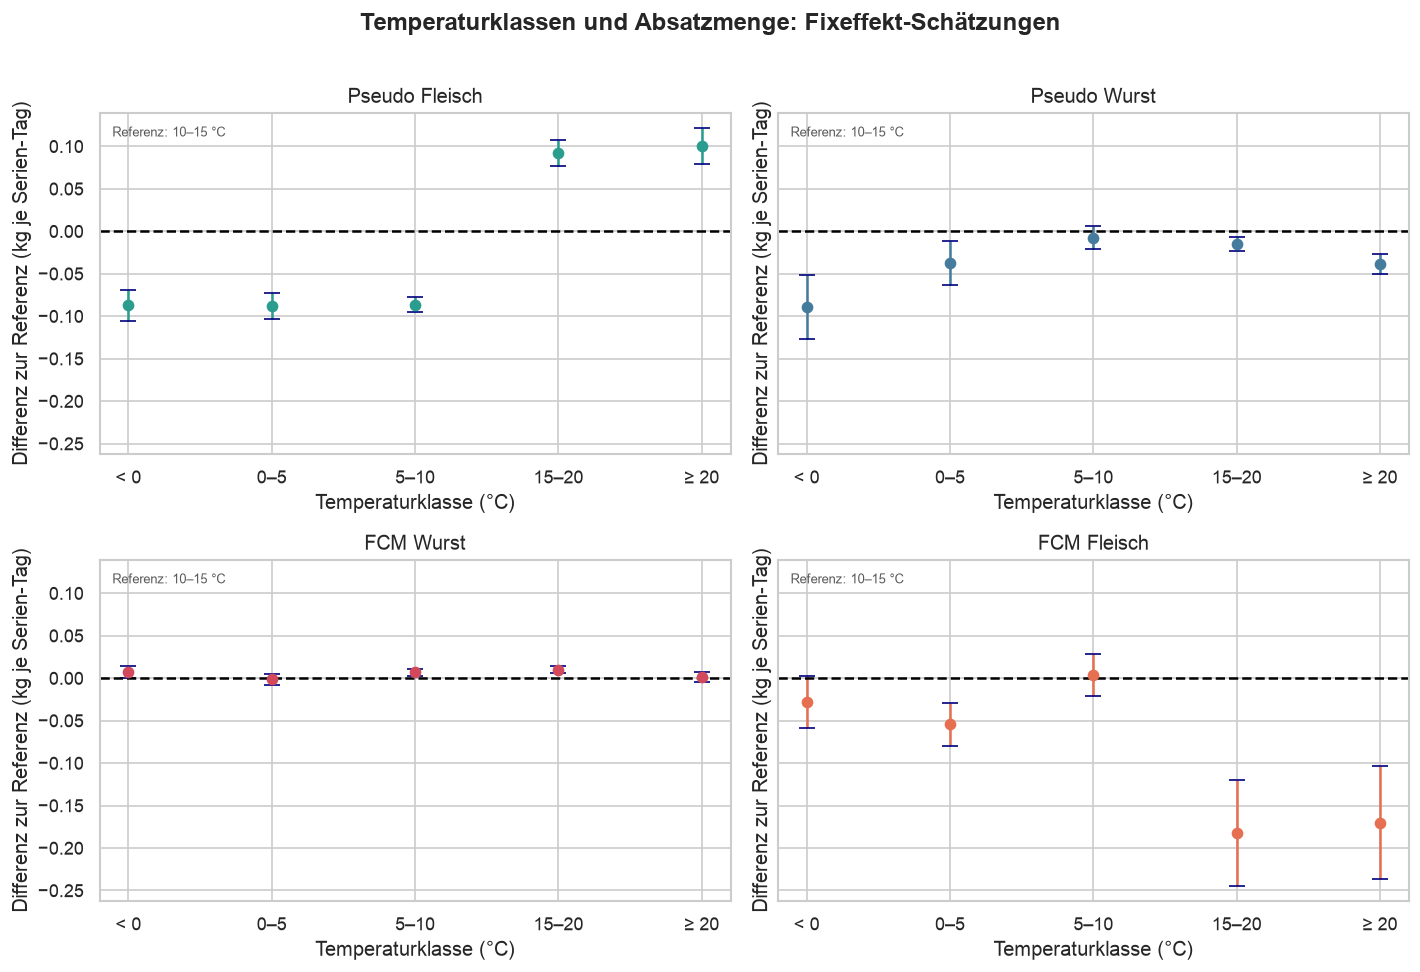

Bins with fewer than 15 distinct trading days per group are not estimated or plotted.

group,Pseudo Fleisch,Pseudo Wurst,FCM Wurst,FCM Fleisch
temperature_bin,,,,
< 0,84,75,41,39
0–5,221,172,85,79
5–10,374,296,147,120
10–15,361,295,173,108
15–20,326,284,149,50
≥ 20,125,103,57,26


In [14]:
TEMPERATURE_EDGES = [-np.inf, 0, 5, 10, 15, 20, np.inf]
TEMPERATURE_LABELS = ["< 0", "0–5", "5–10", "10–15", "15–20", "≥ 20"]
REFERENCE_BIN = "10–15"
MIN_BIN_DAYS = 15
GROUP_CODES = {
    "Pseudo Fleisch": "pseudo_fleisch", "Pseudo Wurst": "pseudo_wurst",
    "FCM Wurst": "fcm_wurst", "FCM Fleisch": "fcm_fleisch",
}
BIN_CODES = {
    "< 0": "lt_0", "0–5": "0_5", "5–10": "5_10",
    "10–15": "10_15", "15–20": "15_20", "≥ 20": "ge_20",
}

estimation_data["temperature_bin"] = pd.cut(
    estimation_data.temp_c, bins=TEMPERATURE_EDGES, labels=TEMPERATURE_LABELS,
    right=False, ordered=True,
)
bin_support = (
    estimation_data.groupby(["group", "temperature_bin"], observed=True)
    .date.nunique().rename("days").reset_index()
)
support_lookup = bin_support.set_index(["group", "temperature_bin"]).days

bin_metadata = []
for source_group in REPORT_GROUP_ORDER:
    for temperature_bin in TEMPERATURE_LABELS:
        days = int(support_lookup.get((source_group, temperature_bin), 0))
        if temperature_bin == REFERENCE_BIN or days < MIN_BIN_DAYS:
            continue
        term = f"tempbin_{GROUP_CODES[source_group]}_{BIN_CODES[temperature_bin]}"
        estimation_data[term] = (
            (estimation_data.group == source_group)
            & (estimation_data.temperature_bin == temperature_bin)
        ).astype("int8")
        bin_metadata.append({
            "group": source_group, "temperature_bin": temperature_bin,
            "days": days, "term": term,
        })
bin_metadata = pd.DataFrame(bin_metadata)
bin_terms = bin_metadata.term.tolist()

BIN_FML = (
    "kg ~ " + " + ".join([
        *bin_terms, "precip_mm:C(group)", "sun_h:C(group)"
    ]) + " | series_id + group^year_month + group^weekday"
)
bin_model = pf.feols(
    BIN_FML, data=estimation_data, vcov={"CRV1": "series_id"},
    copy_data=False, store_data=False, lean=True,
)
estimated_bin_terms = set(bin_model.tidy().index)
estimation_data.drop(columns=bin_terms, inplace=True)

bin_figure, bin_axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for source_group, axis in zip(REPORT_GROUP_ORDER, bin_axes.flat):
    panel_terms = bin_metadata.loc[
        (bin_metadata.group == source_group)
        & bin_metadata.term.isin(estimated_bin_terms)
    ].term.tolist()
    panel_labels = dict(
        bin_metadata.loc[bin_metadata.term.isin(panel_terms), ["term", "temperature_bin"]]
        .itertuples(index=False, name=None)
    )
    bin_model.coefplot(
        keep=panel_terms, exact_match=True, labels=panel_labels,
        coord_flip=False, yintercept=0, rotate_xticks=0,
        title=source_group, plot_backend="matplotlib", ax=axis,
    )
    for artist in axis.lines:
        if artist.get_linestyle() != "--":
            artist.set_color(GROUP_COLORS[source_group])
    for collection in axis.collections:
        collection.set_color(GROUP_COLORS[source_group])
    axis.set_xticks(
        range(len(panel_terms)),
        [panel_labels[term] for term in panel_terms],
    )
    axis.set_xlabel("Temperaturklasse (°C)")
    axis.set_ylabel("Differenz zur Referenz (kg je Serien-Tag)")
    axis.text(
        0.02, 0.96, f"Referenz: {REFERENCE_BIN} °C",
        transform=axis.transAxes, ha="left", va="top",
        fontsize=8, color="0.35",
    )
bin_figure.suptitle(
    "Temperaturklassen und Absatzmenge: Fixeffekt-Schätzungen",
    y=1.01, weight="bold",
)
bin_figure.tight_layout()
display(bin_figure)
plt.close(bin_figure)

support_table = bin_support.pivot(
    index="temperature_bin", columns="group", values="days"
).reindex(index=TEMPERATURE_LABELS, columns=REPORT_GROUP_ORDER)
display(Markdown(
    f"Bins with fewer than {MIN_BIN_DAYS} distinct trading days per group "
    "are not estimated or plotted."
))
display(support_table)

## Automatically generated interpretation

The next cell generates the substantive conclusion from the fitted models. This keeps the prose consistent when the notebook is re-executed with updated transaction or weather data.

In [15]:
def direction_text(row):
    if row.ci_low_kg > 0:
        evidence = "a positive association (95% CI excludes zero)"
    elif row.ci_high_kg < 0:
        evidence = "a negative association (95% CI excludes zero)"
    else:
        evidence = "no statistically clear linear association (95% CI includes zero)"
    return (
        f"- **{row.source_group}:** {row.effect_per_10c_kg:+.3f} kg per active series-day per +10 °C "
        f"(95% CI {row.ci_low_kg:+.3f} to {row.ci_high_kg:+.3f} kg, "
        f"p={row.p_value:.3g}); {evidence}."
    )

effect_lines = [direction_text(row) for row in weather_effects.itertuples(index=False)]
clear_effects = weather_effects[
    (weather_effects.ci_low_kg > 0) | (weather_effects.ci_high_kg < 0)
]
if clear_effects.empty:
    direct_answer = "None of the four sourcing-group temperature slopes has a 95% confidence interval that excludes zero."
else:
    named_groups = ", ".join(clear_effects.source_group)
    direct_answer = f"The 95% confidence interval excludes zero for: {named_groups}."

display(Markdown(
    f"**Direct answer — sourcing-group level.** {direct_answer} The full analysis span is "
    f"{full_start:%d %B %Y} to {full_end:%d %B %Y}; each group contributes its available dates.\n\n"
    + "\n".join(effect_lines)
    + "\n\nAll four slopes come from one pooled series-day fixed-effects model. "
      "The specification absorbs product-store series effects and group-specific year-month and weekday effects, controls for group-specific precipitation and sunshine slopes, and clusters inference by series. "
      "The estimates are conditional associations based on each store's ERA5 cell and do not establish causal weather effects."
))

display(Markdown(
    "**Direct answer — article level, and the conclusion that should be carried forward.** "
    f"Of {len(article_slopes)} articles estimated separately, "
    f"{len(significant_slopes)} "
    f"({len(significant_slopes) / len(article_slopes):.1%}) have a week-clustered 95% "
    f"confidence interval for the temperature slope that excludes zero: "
    f"{positive_significant} positive and {negative_significant} negative. The relative "
    f"effect per +10 °C spans "
    f"{article_slopes.relative_per_10c.quantile(0.10):+.1%} to "
    f"{article_slopes.relative_per_10c.quantile(0.90):+.1%} between the 10th and 90th "
    f"percentile, while its volume-weighted mean is only {volume_weighted_relative:+.2%}. "
    f"Cochran's Q = {cochran_q:,.0f} on {degrees_of_freedom} df with I² = {i_squared:.1%} "
    "confirms that this dispersion is real heterogeneity rather than sampling noise.\n\n"
    "**Therefore:** the near-zero group-level coefficients above must not be read as "
    "'weather does not matter here'. They are the volume-weighted average of large, "
    "mutually cancelling article responses. Any model that uses temperature must let the "
    "slope vary by article; a common slope within a sourcing group is guaranteed to "
    "recover approximately nothing. Because the network's within-day spatial temperature "
    "variation is negligible, the usable signal is the day-level temperature anomaly "
    "interacted with the article, not a store-level weather variable."
))

**Direct answer — sourcing-group level.** The 95% confidence interval excludes zero for: Pseudo Fleisch, FCM Fleisch. The full analysis span is 22 July 2023 to 21 July 2026; each group contributes its available dates.

- **Pseudo Fleisch:** +0.093 kg per active series-day per +10 °C (95% CI +0.079 to +0.106 kg, p=0); a positive association (95% CI excludes zero).
- **Pseudo Wurst:** +0.006 kg per active series-day per +10 °C (95% CI -0.007 to +0.019 kg, p=0.392); no statistically clear linear association (95% CI includes zero).
- **FCM Wurst:** -0.002 kg per active series-day per +10 °C (95% CI -0.007 to +0.002 kg, p=0.331); no statistically clear linear association (95% CI includes zero).
- **FCM Fleisch:** -0.041 kg per active series-day per +10 °C (95% CI -0.062 to -0.020 kg, p=0.000133); a negative association (95% CI excludes zero).

All four slopes come from one pooled series-day fixed-effects model. The specification absorbs product-store series effects and group-specific year-month and weekday effects, controls for group-specific precipitation and sunshine slopes, and clusters inference by series. The estimates are conditional associations based on each store's ERA5 cell and do not establish causal weather effects.

**Direct answer — article level, and the conclusion that should be carried forward.** Of 316 articles estimated separately, 126 (39.9%) have a week-clustered 95% confidence interval for the temperature slope that excludes zero: 86 positive and 40 negative. The relative effect per +10 °C spans -36.9% to +83.1% between the 10th and 90th percentile, while its volume-weighted mean is only +7.09%. Cochran's Q = 2,181 on 315 df with I² = 85.6% confirms that this dispersion is real heterogeneity rather than sampling noise.

**Therefore:** the near-zero group-level coefficients above must not be read as 'weather does not matter here'. They are the volume-weighted average of large, mutually cancelling article responses. Any model that uses temperature must let the slope vary by article; a common slope within a sourcing group is guaranteed to recover approximately nothing. Because the network's within-day spatial temperature variation is negligible, the usable signal is the day-level temperature anomaly interacted with the article, not a store-level weather variable.